In [70]:
import matplotlib
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
import numpy as np
plots.style.use('fivethirtyeight')

# Standard Normal Distribution

"Standard" refers to the fact that the distribution has mean equal to 0 and standard deviation equal to 1.

"Normal" refers to the fact that the distribution is bell-shaped (unimodal) and symmetric.

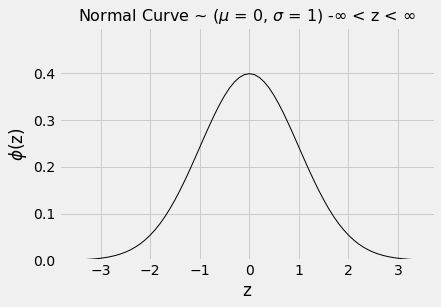

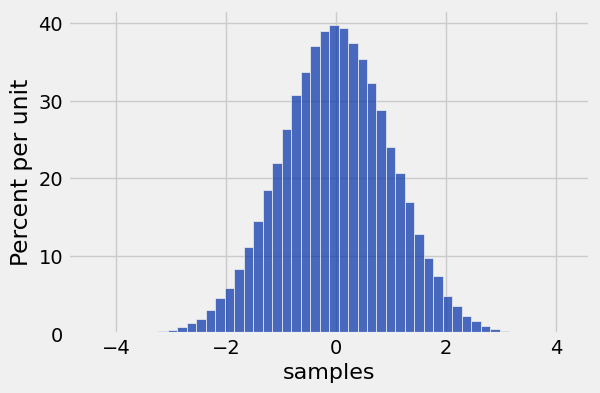

In [71]:
# Random sample of 100,000 values drawn from the standard normal distribution
samples_array = np.random.standard_normal(size=100000)
Table().with_column('samples', samples_array).hist(bins=50)

### What percent of data lies between -1 and 1 on this curve?


In [72]:

# Step 1: Use np.count_nonzero to find the number of values less than -1.
less = np.count_nonzero(samples_array < -1)

# Step 2: Use np.count_nonzero to find the number of values greater than 1.
greater = less = np.count_nonzero(samples_array > 1)

# Step 3: Subtract from the total.
sub = len(samples_array) - less - greater

# Step 4: Convert to a percent.
per = sub/len(samples_array) * 100
per


67.882000000000005

### What percent of data lies between -2 and 2 on this curve?


In [73]:
# Step 1: Use np.count_nonzero to find the number of values less than -1.
less = np.count_nonzero(samples_array < -2)

# Step 2: Use np.count_nonzero to find the number of values greater than 1.
greater = less = np.count_nonzero(samples_array > 2)

# Step 3: Subtract from the total.
sub = len(samples_array) - less - greater

# Step 4: Convert to a percent.
per = sub/len(samples_array) * 100
per

95.553999999999988

### What percent of data lies between -3 and 3 on this curve?

In [74]:
# Step 1: Use np.count_nonzero to find the number of values less than -1.
less = np.count_nonzero(samples_array <= -3)

# Step 2: Use np.count_nonzero to find the number of values greater than 1.
greater = less = np.count_nonzero(samples_array >= 3)

# Step 3: Subtract from the total.
sub = len(samples_array) - less - greater

# Step 4: Convert to a percent.
per = sub/len(samples_array) * 100
per

99.77000000000001

## Bell-Shaped, Symmetric, Nonstandard Distribution

In [75]:
births = Table.read_table('baby.csv')
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


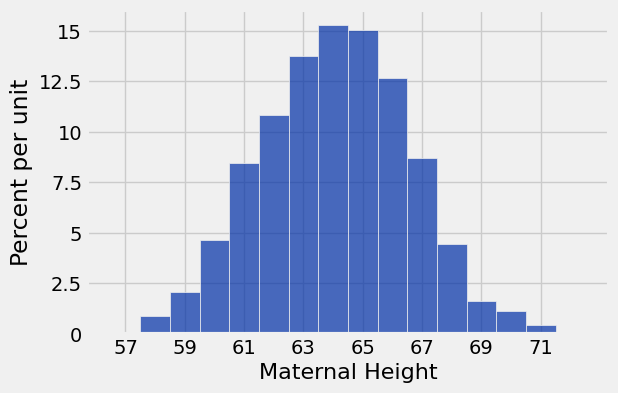

In [76]:

births.hist('Maternal Height', bins = np.arange(56.5, 72.6, 1))
plots.xticks(np.arange(57, 72, 2));

### What percent of the data is at most one standard deviation from the mean?

In [77]:
# Computing the mean and standard deviation
heights = births.column('Maternal Height')
print(np.mean(heights))
print(np.std(heights))

64.0494037479
2.52502544097


### What percent of the data is at most 1 standard deviations from the mean?

In [78]:
less = np.count_nonzero(heights <= (np.mean(heights) -  np.std(heights)))

# Step 2: Use np.count_nonzero to find the number of values greater than 1.
greater= np.count_nonzero(heights >= np.mean(heights) +  np.std(heights))

# Step 3: Subtract from the total.
sub = len(heights) - less - greater

# Step 4: Convert to a percent.
per = sub/len(heights) * 100
per

67.376490630323687

### What percent of the data is at most two standard deviations from the mean?

In [79]:
# Step 2: Use np.count_nonzero to find the number of values less than 2 std.
less = np.count_nonzero(heights <= (np.mean(heights) - 2 * np.std(heights)))

# Step 2: Use np.count_nonzero to find the number of values greater than 2 std.
greater= np.count_nonzero(heights >= np.mean(heights) + 2 * np.std(heights))

# Step 3: Subtract from the total.
sub = len(heights) - less - greater

# Step 4: Convert to a percent.
per = sub/len(heights) * 100
per

97.189097103918229

### What percent of the data is at most three standard deviations from the mean?

In [80]:
# Step 2: Use np.count_nonzero to find the number of values less than 3 std.
less = np.count_nonzero(heights <= np.mean(heights) - 3 * np.std(heights))

# Step 2: Use np.count_nonzero to find the number of values greater than 3 std.
greater= np.count_nonzero(heights >= np.mean(heights) + 3 * np.std(heights))

# Step 3: Subtract from the total.
sub = len(heights) - less - greater

# Step 4: Convert to a percent.
per = sub/len(heights) * 100
per

99.659284497444631

Write a function called bounded_by_sd. It takes two inputs: data_arr and num_sd. The function should return the percent of the data in data_arr that is at most num_sd standard deviations from the mean.

In [81]:
def bounded_by_sd(data_arr,num_sd):
    less = np.count_nonzero(data_arr <= np.mean(data_arr) - num_sd * np.std(data_arr))

    # Step 2: Use np.count_nonzero to find the number of values greater than 1.
    greater= np.count_nonzero(data_arr >= np.mean(data_arr) + num_sd * np.std(data_arr))

    # Step 3: Subtract from the total.
    sub = len(data_arr) - less - greater

    # Step 4: Convert to a percent.
    per = sub/len(data_arr) * 100
    return per

In [82]:
# Test the function on the heights array.
bounded_by_sd(heights,2)

97.189097103918229

## Summary of "The Empirical Rule"

For bell-shaped and symmetric distributions:

mean ± 1 SD captures about 68% of the data

mean ± 2 SDs captures about 95% of the data

mean ± 3 SDs captures about 99.73% of the data